In [1]:
# ============================================================
# Stage 6: Clinical Behavioral Association and Prediction Analysis
# Cell 1: Data loading and alignment (consistently using META_PATH)
# ============================================================
import os
import pickle
import pandas as pd
import numpy as np

from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("✓ Google Drive 已挂载")

print("="*60)
print("🚀 开始 Stage 6: 加载临床数据与组学特征")
print("="*60)

# 1. Path setup
BASE_PATH = '/content/drive/MyDrive/ASD_Research'
DATA_PATH = os.path.join(BASE_PATH, '02_merged_data')
META_PATH = os.path.join(BASE_PATH, '03_metadata_tables') # 修改为 META_PATH
FIG_PATH = os.path.join(BASE_PATH, '04_figures')
os.makedirs(FIG_PATH, exist_ok=True)

# 2. Redefine the matrix construction function (to ensure standalone execution works)
def build_matrix_robust(data_dict, feature_dict, group_series):
    X_list = []
    for dtype, feats in feature_dict.items():
        if not feats: continue
        if dtype not in data_dict or data_dict[dtype] is None: continue
        df_full = data_dict[dtype]
        if dtype == 'taxa':
            idx_keep = [i for i in df_full.index if 's__' in i and 't__' not in i]
            df_full = df_full.loc[idx_keep]
            df_full.index = [i.split('s__')[-1].replace('_', ' ') for i in df_full.index]
        existing = [f for f in feats if f in df_full.index]
        part_exist = df_full.loc[existing].T
        part_exist = part_exist[existing]
        part_exist.columns = [f"{dtype}|{c}" for c in part_exist.columns]
        X_list.append(part_exist)
    if not X_list:
        raise ValueError("没有找到任何特征数据！")
    X_final = pd.concat(X_list, axis=1)
    common = X_final.index.intersection(group_series.index)
    return X_final.loc[common], group_series.loc[common]

# 3. Load results from Stage 2 and Stage 5
print("正在加载组学特征...")
with open(os.path.join(DATA_PATH, 'stage2_normalized_data.pkl'), 'rb') as f:
    stage2_data = pickle.load(f)
with open(os.path.join(DATA_PATH, 'stage5_ml_results.pkl'), 'rb') as f:
    stage5_results = pickle.load(f)

discovery_data = stage2_data['discovery_data_corrected']
discovery_group = stage2_data['discovery_group']
target_features = stage5_results['feature_list']

# Build the strictly selected feature matrix
X_omics, y_omics = build_matrix_robust(discovery_data, target_features, discovery_group)

# 4. Load clinical data
print(f"正在加载临床评分数据 ({META_PATH})...")
clin_csv_path = os.path.join(META_PATH, 'Table4_Clinical_Behavior_Scores.csv')
clin_df = pd.read_csv(clin_csv_path)

# Smart alignment: trim leading/trailing spaces and set the index
clin_df['Sample_ID'] = clin_df['Sample_ID'].astype(str).str.strip()
clin_df.set_index('Sample_ID', inplace=True)

# Align by the intersection
common_samples = X_omics.index.intersection(clin_df.index)

if len(common_samples) == 0:
    print("❌ 警告: 样本 ID 无法直接匹配！")
    print(f"  组学样本名示例: {X_omics.index[:3].tolist()}")
    print(f"  临床样本名示例: {clin_df.index[:3].tolist()}")
else:
    X_matched = X_omics.loc[common_samples]
    clin_matched = clin_df.loc[common_samples]

    # Extract the ASD group for core correlation analysis
    asd_mask = clin_matched['Group'] == 'ASD'
    X_asd = X_matched[asd_mask]
    clin_asd = clin_matched[asd_mask]

    print(f"✅ 对齐成功！共匹配到 {len(common_samples)} 个长春队列样本。")
    print(f"  - 其中 ASD 患儿: {len(X_asd)} 例 (将用于深入分析)")
    print(f"  - 可用临床评分: {', '.join([c for c in clin_df.columns if 'Ability' in c or 'Score' in c])}")

Mounted at /content/drive
✓ Google Drive 已挂载
🚀 开始 Stage 6: 加载临床数据与组学特征
正在加载组学特征...
正在加载临床评分数据 (/content/drive/MyDrive/ASD_Research/03_metadata_tables)...
✅ 对齐成功！共匹配到 70 个长春队列样本。
  - 其中 ASD 患儿: 35 例 (将用于深入分析)
  - 可用临床评分: ABC_Total_Score, Sensory_Ability, Social_Ability, Motor_Ability, Language_Ability, Self_Care_Ability



🚀 任务1: 计算多组学特征与 ABC 评分的相关性


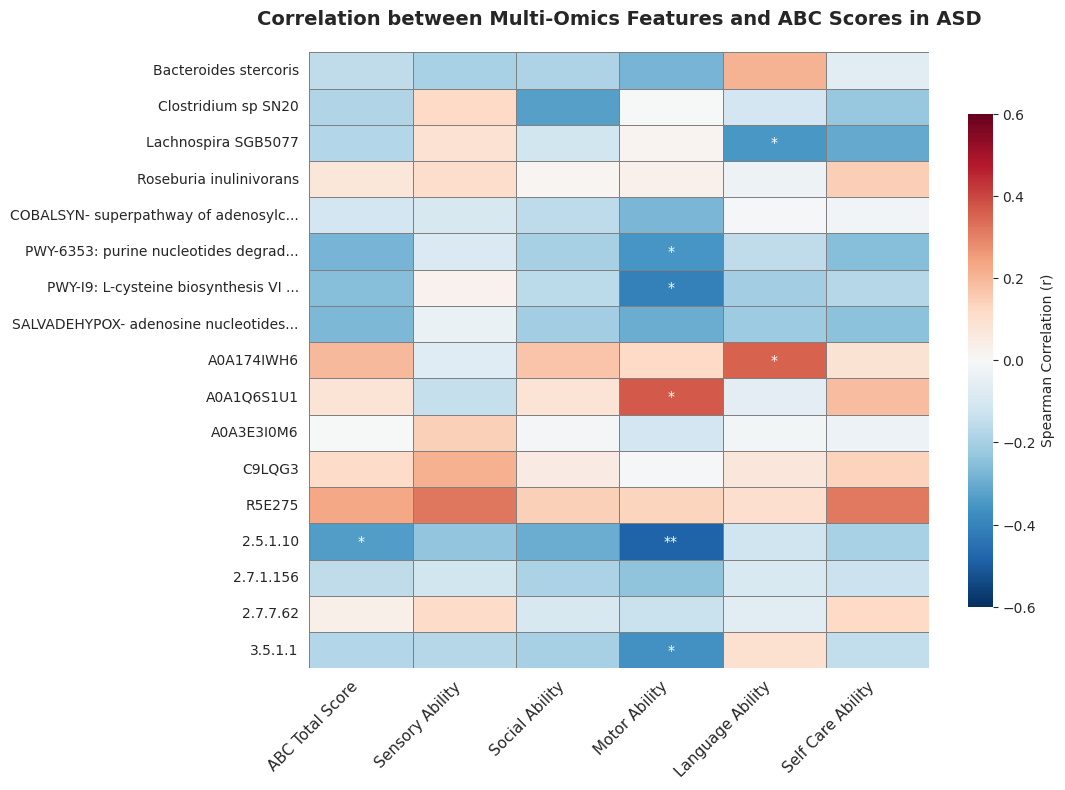

✓ 相关性热图已保存至: /content/drive/MyDrive/ASD_Research/04_figures/Fig4A_Clinical_Correlation_Heatmap.pdf
  (说明: 红色代表正相关/加重症状，蓝色代表负相关/保护作用。* P<0.05, ** P<0.01)


In [3]:
# ============================================================
# Cell 2: Spearman correlation analysis and heatmap with significance stars
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr  # 👈 确保核心计算函数被成功导入

print("\n" + "="*60)
print("🚀 任务1: 计算多组学特征与 ABC 评分的相关性")
print("="*60)

# Define the clinical variables to analyze
clin_cols = ['ABC_Total_Score', 'Sensory_Ability', 'Social_Ability',
             'Motor_Ability', 'Language_Ability', 'Self_Care_Ability']

# Initialize result matrices
corr_matrix = pd.DataFrame(index=X_asd.columns, columns=clin_cols, dtype=float)
pval_matrix = pd.DataFrame(index=X_asd.columns, columns=clin_cols, dtype=float)

# Compute Spearman correlations within the ASD group
for feat in X_asd.columns:
    for clin in clin_cols:
        # Remove samples that may contain missing values (NaN)
        valid_idx = X_asd[feat].notna() & clin_asd[clin].notna()
        r, p = spearmanr(X_asd.loc[valid_idx, feat], clin_asd.loc[valid_idx, clin])
        corr_matrix.loc[feat, clin] = r
        pval_matrix.loc[feat, clin] = p

# Clean feature names (remove redundant prefixes for better visualization)
def clean_feat_name(name):
    clean = name.split('|')[1].replace('UniRef90_', '').replace('PWY:', '')
    return clean[:35] + '...' if len(clean) > 35 else clean

corr_matrix.index = [clean_feat_name(i) for i in corr_matrix.index]
pval_matrix.index = [clean_feat_name(i) for i in pval_matrix.index]
corr_matrix.columns = [c.replace('_', ' ') for c in corr_matrix.columns]

# Generate the significance-star matrix
def get_stars(p):
    if p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

annot_matrix = pval_matrix.map(get_stars)

# Draw a publication-style heatmap
plt.figure(figsize=(10, 8))
sns.set_style("white")

ax = sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='RdBu_r',       # 蓝-白-红 渐变
    center=0,            # 0 为白色
    vmin=-0.6, vmax=0.6, # 限制色带范围，增强对比
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Spearman Correlation (r)', 'shrink': 0.8}
)

plt.title('Correlation between Multi-Omics Features and ABC Scores in ASD',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=10)

# Adjust tick orientation (Nature style)
ax.tick_params(direction='out', length=4, width=1)

out_fig2 = os.path.join(FIG_PATH, 'Fig4A_Clinical_Correlation_Heatmap.pdf')
plt.savefig(out_fig2, bbox_inches='tight')
plt.show()

print(f"✓ 相关性热图已保存至: {out_fig2}")
print("  (说明: 红色代表正相关/加重症状，蓝色代表负相关/保护作用。* P<0.05, ** P<0.01)")


🚀 任务2: 提取核心特征绘制临床回归散点图
✅ 找到最强显著相关组合: '2.5.1.10' vs 'Motor_Ability'


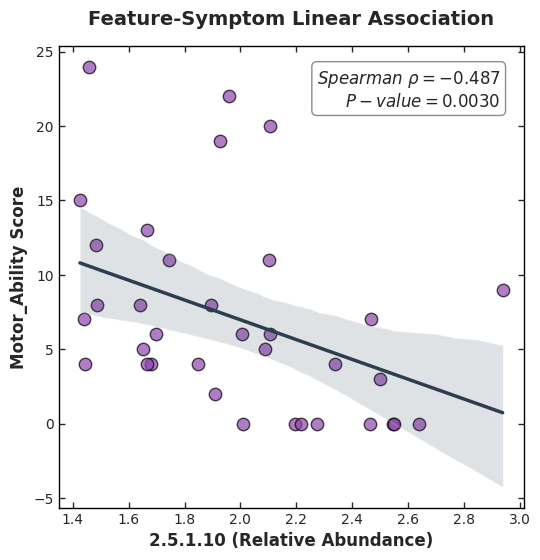


✓ 单变量回归图已保存至: /content/drive/MyDrive/ASD_Research/04_figures/Fig4B_Univariate_Regression.pdf


In [8]:
# ============================================================
# Cell 3 (pivot version): Univariate clinical regression analysis of core biomarkers (robust fixed version)
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

print("\n" + "="*60)
print("🚀 任务2: 提取核心特征绘制临床回归散点图")
print("="*60)

# 1. Dependency check
if 'corr_matrix' not in globals() or 'pval_matrix' not in globals():
    raise NameError("❌ 错误: 未找到热图计算结果。请先运行 Cell 2！")

# 2. Find the most significant feature-symptom pair (smallest P-value)
p_unstacked = pval_matrix.unstack()
significant_pairs = p_unstacked[p_unstacked < 0.05].sort_values()

if len(significant_pairs) == 0:
    print("⚠ 提示: 没有发现与临床评分 P<0.05 的显著相关。")
    best_clin, best_feat = p_unstacked.idxmin()
else:
    best_clin, best_feat = significant_pairs.index[0]

print(f"✅ 找到最强显著相关组合: '{best_feat}' vs '{best_clin}'")

# 3. Robustly map back to original column names (fully resolve KeyError)
def clean_str(s):
    """Remove all spaces and underscores and convert to lowercase for exact matching."""
    return str(s).replace(' ', '').replace('_', '').lower()

# 3.1 Intelligently match clinical columns
target_clin = clean_str(best_clin)
orig_clin_name = None
for c in clin_asd.columns:
    if clean_str(c) == target_clin:
        orig_clin_name = c
        break
if orig_clin_name is None:
    raise KeyError(f"无法在临床表匹配到: {best_clin}。可用列: {clin_asd.columns.tolist()}")

# 3.2 Intelligently match feature columns
target_feat = clean_str(best_feat)
orig_feat_name = None
for c in X_asd.columns:
    # Extract the core feature name for matching
    c_simplified = clean_str(c.split('|')[-1].replace('UniRef90', '').replace('PWY:', ''))
    if target_feat in c_simplified or target_feat in clean_str(c):
        orig_feat_name = c
        break
if orig_feat_name is None:
    raise KeyError(f"无法在组学特征中匹配到: {best_feat}。")

# 4. Prepare plotting data (force conversion to float and drop missing values)
plot_df = pd.DataFrame({
    'Feature_Abundance': X_asd[orig_feat_name].astype(float),
    'Clinical_Score': clin_asd[orig_clin_name].astype(float)
}).dropna()

# 5. Compute the correlation
r, p = spearmanr(plot_df['Feature_Abundance'], plot_df['Clinical_Score'])

# 6. Plot (publication-style univariate regression figure)
plt.figure(figsize=(6, 6))
sns.set_style("ticks")

ax = sns.regplot(
    x='Feature_Abundance',
    y='Clinical_Score',
    data=plot_df,
    scatter_kws={'s': 80, 'alpha': 0.7, 'edgecolor': 'k', 'color': '#8E44AD'}, # 高级紫色散点
    line_kws={'lw': 2.5, 'color': '#2C3E50'}, # 深空蓝色趋势线
    ci=95 # 95% 置信区间
)

# Style the figure
plt.xlabel(f'{best_feat} (Relative Abundance)', fontsize=12, fontweight='bold')
plt.ylabel(f'{best_clin} Score', fontsize=12, fontweight='bold')
plt.title('Feature-Symptom Linear Association', fontsize=14, fontweight='bold', pad=15)

# Dynamically place the statistics textbox (to avoid covering data points)
textstr = '\n'.join((
    r'$Spearman\ \rho=%.3f$' % (r, ),
    r'$P-value=%.4f$' % (p, )))

if r > 0:
    loc = 'upper left'
    bbox_x, bbox_y = 0.05, 0.95
else:
    loc = 'upper right'
    bbox_x, bbox_y = 0.95, 0.95

props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(bbox_x, bbox_y, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment=loc.split(' ')[1], bbox=props)

# Border settings (Nature style)
ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor('black')

out_fig3 = os.path.join(FIG_PATH, 'Fig4B_Univariate_Regression.pdf')
plt.savefig(out_fig3, bbox_inches='tight')
plt.show()

print(f"\n✓ 单变量回归图已保存至: {out_fig3}")


🚀 任务2: 批量提取所有显著特征并逐一绘制独立散点图


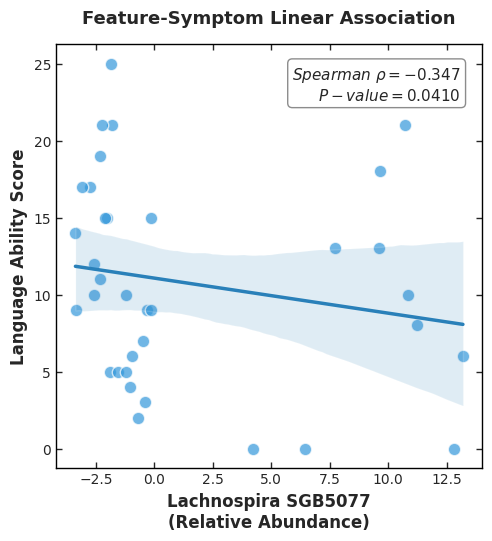

✅ 生成独立图表: Lachnospira SGB5077 vs Language Ability
   └─ 保存为: Fig4B_1_Lachnospira_SGB5077_Language_Ability.pdf



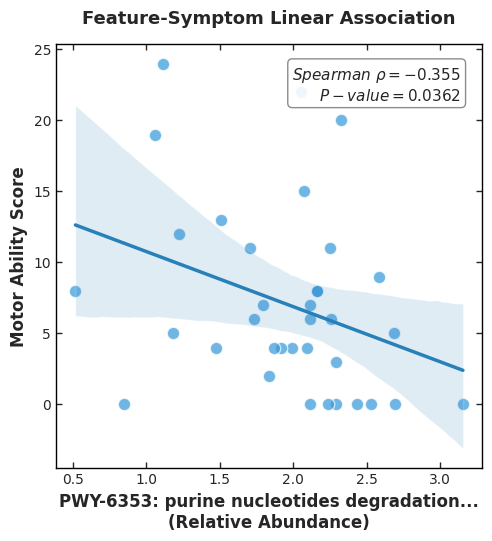

✅ 生成独立图表: PWY-6353: purine nucleotides degradation... vs Motor Ability
   └─ 保存为: Fig4B_2_PWY_6353__purine_nuc_Motor_Ability.pdf



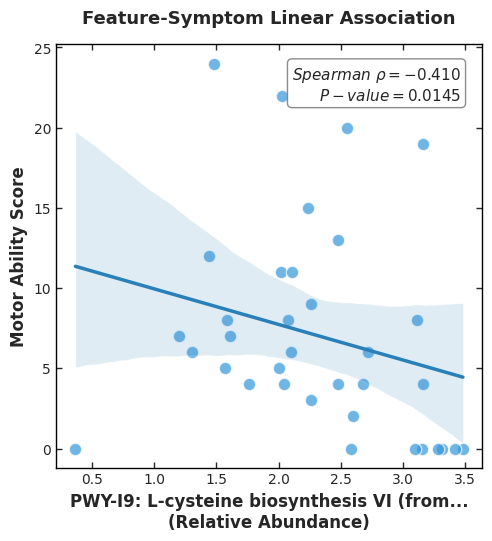

✅ 生成独立图表: PWY-I9: L-cysteine biosynthesis VI (from... vs Motor Ability
   └─ 保存为: Fig4B_3_PWY_I9__L_cysteine_b_Motor_Ability.pdf



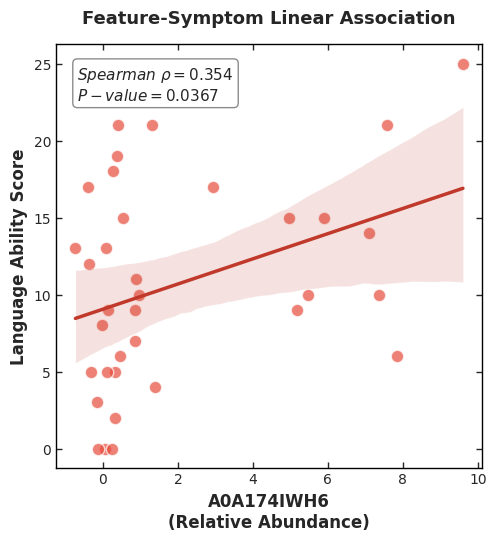

✅ 生成独立图表: A0A174IWH6 vs Language Ability
   └─ 保存为: Fig4B_4_A0A174IWH6_Language_Ability.pdf



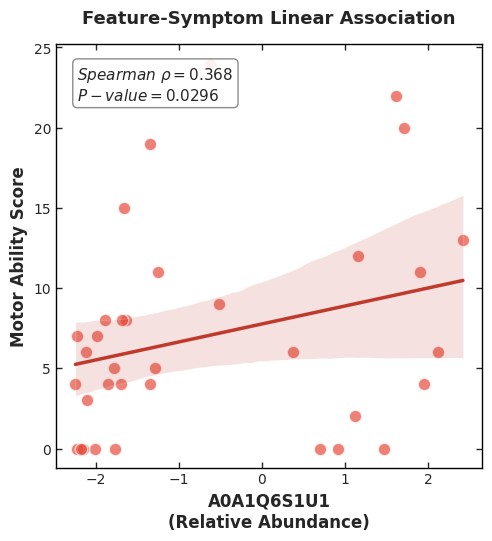

✅ 生成独立图表: A0A1Q6S1U1 vs Motor Ability
   └─ 保存为: Fig4B_5_A0A1Q6S1U1_Motor_Ability.pdf



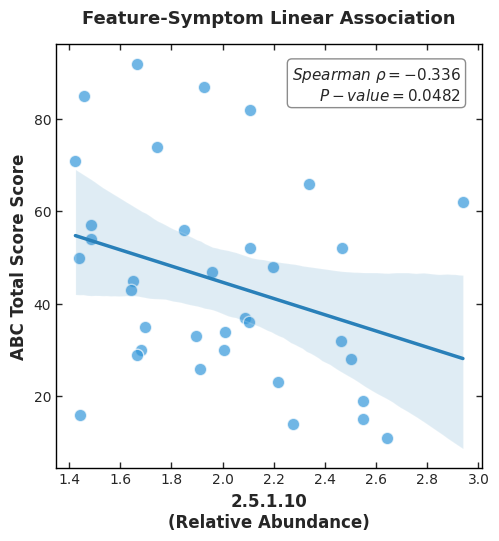

✅ 生成独立图表: 2.5.1.10 vs ABC Total Score
   └─ 保存为: Fig4B_6_2_5_1_10_ABC_Total_Score.pdf



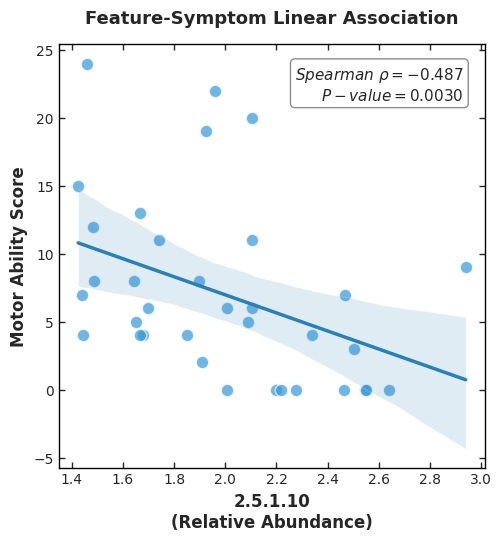

✅ 生成独立图表: 2.5.1.10 vs Motor Ability
   └─ 保存为: Fig4B_7_2_5_1_10_Motor_Ability.pdf



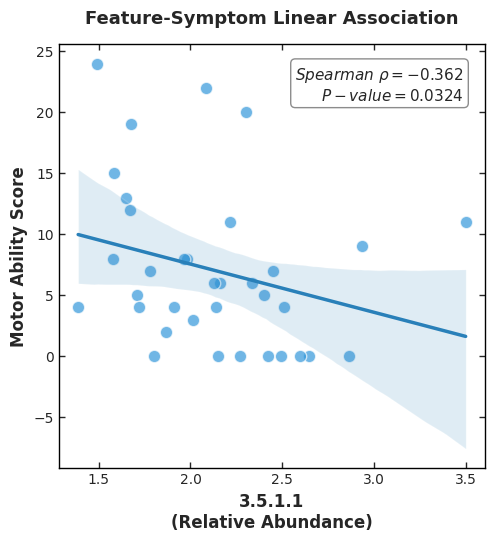

✅ 生成独立图表: 3.5.1.1 vs Motor Ability
   └─ 保存为: Fig4B_8_3_5_1_1_Motor_Ability.pdf

🎉 大功告成！全部 8 张独立散点图已生成并保存在 04_figures 目录下，方便您排版使用！


In [10]:
# ============================================================
# Cell 3 (standalone plotting version): Batch-extract significant features and draw separate scatter plots
# ============================================================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

print("\n" + "="*60)
print("🚀 任务2: 批量提取所有显著特征并逐一绘制独立散点图")
print("="*60)

# 1. Clinical variables
clin_cols = ['ABC_Total_Score', 'Sensory_Ability', 'Social_Ability',
             'Motor_Ability', 'Language_Ability', 'Self_Care_Ability']

count = 0

# 2. Iterate directly over the raw matrix (to fully avoid matching failures caused by truncated names)
for feat in X_asd.columns:
    for clin in clin_cols:
        # Extract data after removing missing values
        valid_idx = X_asd[feat].notna() & clin_asd[clin].notna()
        data_x = X_asd.loc[valid_idx, feat].astype(float)
        data_y = clin_asd.loc[valid_idx, clin].astype(float)

        # Skip if there are too few samples
        if len(data_x) < 5:
            continue

        # Compute the correlation
        r, p = spearmanr(data_x, data_y)

        # Draw a separate figure whenever P < 0.05
        if p < 0.05:
            count += 1

            # --- Extract a clean feature label for plotting ---
            raw_feat_name = feat.split('|')[-1].replace('UniRef90_', '').replace('PWY:', '')
            display_name = raw_feat_name[:40] + '...' if len(raw_feat_name) > 40 else raw_feat_name
            clin_display = clin.replace('_', ' ')

            # --- 1. Create a standalone canvas ---
            plt.figure(figsize=(5.5, 5.5))
            sns.set_style("ticks")

            # Color scheme: red tones for positive correlations, blue tones for negative correlations
            color_scatter = '#E74C3C' if r > 0 else '#3498DB'
            color_line = '#C0392B' if r > 0 else '#2980B9'

            plot_df = pd.DataFrame({'Feature': data_x, 'Clinical': data_y})

            # --- 2. Draw scatter regression with a confidence interval ---
            ax = sns.regplot(
                x='Feature',
                y='Clinical',
                data=plot_df,
                scatter_kws={'s': 80, 'alpha': 0.7, 'edgecolor': 'w', 'color': color_scatter},
                line_kws={'lw': 2.5, 'color': color_line},
                ci=95
            )

            # --- 3. Style the figure ---
            plt.xlabel(f'{display_name}\n(Relative Abundance)', fontsize=12, fontweight='bold')
            plt.ylabel(f'{clin_display} Score', fontsize=12, fontweight='bold')
            plt.title('Feature-Symptom Linear Association', fontsize=13, fontweight='bold', pad=15)

            # Statistics textbox
            textstr = '\n'.join((
                r'$Spearman\ \rho=%.3f$' % (r, ),
                r'$P-value=%.4f$' % (p, )))

            loc = 'upper left' if r > 0 else 'upper right'
            bbox_x = 0.05 if r > 0 else 0.95

            props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
            ax.text(bbox_x, 0.95, textstr, transform=ax.transAxes, fontsize=11,
                    verticalalignment='top', horizontalalignment=loc.split(' ')[1], bbox=props)

            # Border settings (Nature style)
            ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
            for spine in ax.spines.values():
                spine.set_linewidth(1.0)
                spine.set_edgecolor('black')

            # --- 4. Robustly save each individual file ---
            # Replace special characters that might trigger filesystem errors
            safe_feat_name = re.sub(r'[^a-zA-Z0-9]', '_', raw_feat_name[:20])
            out_filename = f'Fig4B_{count}_{safe_feat_name}_{clin}.pdf'
            out_path = os.path.join(FIG_PATH, out_filename)

            plt.savefig(out_path, bbox_inches='tight')
            plt.show() # 在 Notebook 中逐一展示

            print(f"✅ 生成独立图表: {display_name} vs {clin_display}")
            print(f"   └─ 保存为: {out_filename}\n")

if count == 0:
    print("⚠ 提示: 没有发现 P<0.05 的显著相关组合。")
else:
    print(f"🎉 大功告成！全部 {count} 张独立散点图已生成并保存在 04_figures 目录下，方便您排版使用！")